# **PONTIFICIA UNIVERSIDAD JAVERIANA**
## **Procesamiento de alto volumen de datos**
**Fecha:** 8 de Abril del 2026

**Autor:** Grupo Sigma

**Tema:** Proyecto de Big Data

**Objetivo:** 
- Entender la importancia del uso de herramientas de Big Data en entornos empresariales, a fin de poder solucionar preguntas de negocio.
- Entender el paso a paso de un proyecto de procesamiento de datos para la generación de hallazgos de valor basado en la metodología CRISP-DM.
- Documentar la implementación de un cluster como infraestructura de procesamiento de grandes volúmenes de datos, a través de máquinas virtuales
- Realizar procesamiento de datos aplicado a un problema real.

**Version:** Entrega 1

Para asegurar que el proyecto funcione correctamente con pandas, matplotlib, seaborn y findspark, ejecutar el siguiente comando desde la raíz del proyecto
```bash
pip install -r requirements.txt
```

In [1]:
### Importación de bibliotecas basicas 
import os                       # -> Para gestion de archivos y procesos
import sys                      # -> Para manejo de recursos del sistema
import pandas as pd             # -> Para graficar y objetos dataframe
import numpy as np              # -> Para algebra matricial
import matplotlib.pyplot as plt # -> Para formatos de graficas
import seaborn as sns           # -> Para estadistica y graficar

In [2]:
### Importacion de bibliotecas especializadas
import findspark                                # -> Para manejo del entorno de PySpark
findspark.init('/Almacen/Spark')                # -> Se inicia el entorno para PySpark
from pyspark import SparkConf, SparkContext     # -> Para contexto y configuración de PySpark
from pyspark.sql import SparkSession            # -> Para manejo de Sesion en entorno de consultas SQL
from pyspark.sql.functions import *             # -> Para funciones de manipulacion de columnas
from pyspark.sql.types import IntegerType, StringType, DoubleType # -> Para definir tipos de datos


In [3]:
configura = SparkConf()
configura.set('spark.scheduler.mode', 'FAIR')
configura.set('spark.scheduler.allocation','/Almacen/Spark/conf/fairscheduler.xml')
configura.setMaster('spark://10.43.97.166:7077')
configura.setAppName('SigmaSPARK')

sparkSigma = SparkSession.builder.config(conf=configura).getOrCreate()
sparkSigma

In [4]:
## Se crea el dataframe para acceder al sistema de fichero csv como un objeto dataframe pyspark
## El acceso se hara desde el sistema de ficheros Hadoop HDFS
dfPy00 = sparkSigma.read.format("csv").option("header","true").option("encoding", "ISO-8859-1").load("../data/Internet_Fijo_Accesos_por_tecnología_y_segmento_20260407.csv")
dfPy00.show(5)

+----+---------+--------------------+----------------+------------+-------------+--------------------+--------------------+----------+----------------+----------------+-------------+
|AÃO|TRIMESTRE|           PROVEEDOR|COD_DEPARTAMENTO|DEPARTAMENTO|COD_MUNICIPIO|           MUNICIPIO|            SEGMENTO|TECNOLOGIA|VELOCIDAD_BAJADA|VELOCIDAD_SUBIDA|No DE ACCESOS|
+----+---------+--------------------+----------------+------------+-------------+--------------------+--------------------+----------+----------------+----------------+-------------+
|2018|        1|         EDATEL S.A.|              05|   ANTIOQUIA|        05042|SANTAFÃ DE ANTIO...|         CORPORATIVO|      XDSL|            8,00|            1,00|           25|
|2019|        1|AXESS NETWORKS SO...|              52|     NARIÃO|        52473|            MOSQUERA|         CORPORATIVO| SATELITAL|            0,06|            0,06|            2|
|2019|        1|TELMEX COLOMBIA S.A.|              25|CUNDINAMARCA|        25269|    

**Se hace la introduccion sobre los datos de "Accesos de Internet Fijo por Tecnología y Segmento" almacenados sobre datos estructurados "csv"**

### **Análisis de la Fuente de Datos**

Tras la carga inicial del conjunto de datos mediante PySpark, se procede a realizar una interpretación técnica y de negocio de la información disponible. Este dataset permite caracterizar la cobertura y distribución del servicio de internet fijo en Colombia a nivel municipal.

#### Resumen de Metadatos

- Nombre del Dataset: Internet Fijo - Accesos por Tecnología y Segmento.
- Entidad Origen: Ministerio de Tecnologías de la Información y las Comunicaciones (MinTIC).
- Volumen de Datos: Aproximadamente 2.79 Millones de filas y 12 columnas.
- Granularidad: Cada registro representa la cantidad de accesos de un proveedor específico, en un municipio, segmento de mercado, tecnología y velocidad determinados, para un trimestre y año dado.

#### Estructura de las Variables

El dataset se organiza en cuatro dimensiones principales:
1. Identificación Temporal: Variables AÑO y TRIMESTRE que permiten construir series de tiempo trimestrales desde 2018.
2. Identificación Geográfica: Códigos DIVIPOLA de departamento y municipio, junto con sus nombres, que permiten cruzar con otros datasets del proyecto.
3. Caracterización del Servicio: Variables PROVEEDOR, SEGMENTO y TECNOLOGIA que detallan quién presta el servicio, a qué tipo de usuario y mediante qué infraestructura.
4. Métricas de Calidad y Cobertura: VELOCIDAD_BAJADA, VELOCIDAD_SUBIDA y No DE ACCESOS, que cuantifican tanto la calidad técnica del servicio como su alcance poblacional.



### **Análisis preliminar**

Al observar las primeras 5 filas, se lograron identificar los siguientes puntos para la fase de Preparación de Datos:
- Problemas de Encoding: Se detectan caracteres mal codificados en los nombres de municipios y departamentos (ej. 'SANTAFÃ DE ANTIOQUIA' en lugar de 'SANTAFÉ DE ANTIOQUIA'). Esto se origina en la codificación ISO-8859-1 del archivo fuente y requiere tratamiento explícito.
- Tipado de Datos: Las columnas VELOCIDAD_BAJADA y VELOCIDAD_SUBIDA son leídas como String debido al uso de coma como separador decimal. Se requiere reemplazar la coma por punto y aplicar casting a DoubleType.
- Nombre de Columna con Carácter Especial: La columna 'No DE ACCESOS' contiene un carácter especial que puede causar errores en operaciones de Spark. Se debe renombrar a un identificador estándar.
- Valores Nulos Geográficos: Se detectaron 5 nulos en COD_DEPARTAMENTO y 10 en COD_MUNICIPIO, que deben ser tratados antes de cualquier análisis territorial.

### **Diagnóstico y tratamiento de datos sobre Pyspark**

- **1** Cambio de nombre de columnas
- **2** Tipos y coherencia de datos
- **3** Identificación y tratamiento de nulos 
- **4** Estadísticas generales
- **5** Categorías y cambio sobre el tipo de datos de las categorías

### 1 - Cambio de nombre de columnas

In [5]:
### Se despliega las columnas
dfPy00.columns

['AÃ\x91O',
 'TRIMESTRE',
 'PROVEEDOR',
 'COD_DEPARTAMENTO',
 'DEPARTAMENTO',
 'COD_MUNICIPIO',
 'MUNICIPIO',
 'SEGMENTO',
 'TECNOLOGIA',
 'VELOCIDAD_BAJADA',
 'VELOCIDAD_SUBIDA',
 'No DE ACCESOS']

In [6]:
## Se listan los nombres de las columnas actuales y los nombres nuevos del dataframe  
NombresOriginales = [
    'AÃ\x910', 'TRIMESTRE', 'PROVEEDOR',
    'COD_DEPARTAMENTO', 'DEPARTAMENTO',
    'COD_MUNICIPIO', 'MUNICIPIO',
    'SEGMENTO', 'TECNOLOGIA',
    'VELOCIDAD_BAJADA', 'VELOCIDAD_SUBIDA',
    'No DE ACCESOS'
]

NombresNuevos = [
    'AÑO', 'TRIMESTRE', 'PROVEEDOR',
    'COD_DEP', 'NOM_DEP',
    'COD_MUN', 'NOM_MUN',
    'SEGMENTO', 'TECNOLOGIA',
    'VEL_BAJADA', 'VEL_SUBIDA',
    'NUM_ACCESOS'
]

dfPy01 = dfPy00.toDF(*NombresNuevos)
dfPy01.columns

['AÑO',
 'TRIMESTRE',
 'PROVEEDOR',
 'COD_DEP',
 'NOM_DEP',
 'COD_MUN',
 'NOM_MUN',
 'SEGMENTO',
 'TECNOLOGIA',
 'VEL_BAJADA',
 'VEL_SUBIDA',
 'NUM_ACCESOS']

In [7]:
dfPy01.show(5)

+----+---------+--------------------+-------+------------+-------+--------------------+--------------------+----------+----------+----------+-----------+
| AÑO|TRIMESTRE|           PROVEEDOR|COD_DEP|     NOM_DEP|COD_MUN|             NOM_MUN|            SEGMENTO|TECNOLOGIA|VEL_BAJADA|VEL_SUBIDA|NUM_ACCESOS|
+----+---------+--------------------+-------+------------+-------+--------------------+--------------------+----------+----------+----------+-----------+
|2018|        1|         EDATEL S.A.|     05|   ANTIOQUIA|  05042|SANTAFÃ DE ANTIO...|         CORPORATIVO|      XDSL|      8,00|      1,00|         25|
|2019|        1|AXESS NETWORKS SO...|     52|     NARIÃO|  52473|            MOSQUERA|         CORPORATIVO| SATELITAL|      0,06|      0,06|          2|
|2019|        1|TELMEX COLOMBIA S.A.|     25|CUNDINAMARCA|  25269|         FACATATIVÃ|         CORPORATIVO|     CABLE|     40,00|      8,00|         55|
|2019|        1|COLOMBIA TELECOMU...|     08|  ATLÃNTICO|  08685|        SA

### 2 - Tipos y coherencia de datos

In [8]:
dfPy01.printSchema()

root
 |-- AÑO: string (nullable = true)
 |-- TRIMESTRE: string (nullable = true)
 |-- PROVEEDOR: string (nullable = true)
 |-- COD_DEP: string (nullable = true)
 |-- NOM_DEP: string (nullable = true)
 |-- COD_MUN: string (nullable = true)
 |-- NOM_MUN: string (nullable = true)
 |-- SEGMENTO: string (nullable = true)
 |-- TECNOLOGIA: string (nullable = true)
 |-- VEL_BAJADA: string (nullable = true)
 |-- VEL_SUBIDA: string (nullable = true)
 |-- NUM_ACCESOS: string (nullable = true)



In [9]:
import pyspark.sql.functions as F

# Inicializamos el dataframe de transformación
dfPy02 = dfPy01

# 1. Casting de variables numéricas enteras
columnas_entero = ['AÑO', 'TRIMESTRE', 'COD_DEP', 'COD_MUN', 'NUM_ACCESOS']
for col_name in columnas_entero:
    dfPy02 = dfPy02.withColumn(col_name, F.col(col_name).cast("int"))

# 2. Casting de velocidades: reemplazar coma por punto y convertir a Double
for col_name in ['VEL_BAJADA', 'VEL_SUBIDA']:
    dfPy02 = dfPy02.withColumn(
        col_name,
        F.regexp_replace(F.col(col_name), ",", ".").cast("double")
    )

# 3. Corrección de encoding en columnas de texto (caracteres especiales)
correcciones = {
    "Ã¡": "A", "Ã©": "E", "Ã­": "I", "Ã³": "O", "Ãº": "U",
    "Ã±": "N", "Ã": "I", "Â°": ""
}
cols_texto = ['NOM_DEP', 'NOM_MUN', 'PROVEEDOR', 'SEGMENTO', 'TECNOLOGIA']
for error, correccion in correcciones.items():
    for c in cols_texto:
        dfPy02 = dfPy02.withColumn(c, F.regexp_replace(F.col(c), error, correccion))

# 4. Estandarización de texto (mayúsculas y sin espacios al inicio/fin)
for c in cols_texto:
    dfPy02 = dfPy02.withColumn(c, F.upper(F.trim(F.col(c))))

# Visualización del esquema final
dfPy02.printSchema()

root
 |-- AÑO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- PROVEEDOR: string (nullable = true)
 |-- COD_DEP: integer (nullable = true)
 |-- NOM_DEP: string (nullable = true)
 |-- COD_MUN: integer (nullable = true)
 |-- NOM_MUN: string (nullable = true)
 |-- SEGMENTO: string (nullable = true)
 |-- TECNOLOGIA: string (nullable = true)
 |-- VEL_BAJADA: double (nullable = true)
 |-- VEL_SUBIDA: double (nullable = true)
 |-- NUM_ACCESOS: integer (nullable = true)



#### **Casting y Normalización de Tipos**

Las transformaciones de tipo aplicadas responden a los siguientes criterios técnicos:

| Variable | Tipo Original | Tipo Final | Justificación |
| :--- | :---: | :---: | :--- |
| **AÑO** | String | Integer | Permite filtros y agrupaciones temporales numéricas. |
| **TRIMESTRE** | String | Integer | Necesario para ordenamiento cronológico correcto. |
| **COD_DEP / COD_MUN** | String | Integer | Facilita joins con otros datasets por código DIVIPOLA. |
| **NUM_ACCESOS** | String | Integer | Permite operaciones de suma y promedio para agregaciones. |
| **VEL_BAJADA / VEL_SUBIDA** | String | Double | La coma decimal del origen impide el casting directo; requiere sustitución previa. |

#### **Normalización de Texto**

- Corrección de Encoding: Se aplicó una limpieza mediante expresiones regulares para corregir caracteres rotos (ISO-8859-1) en nombres de departamentos, municipios y tecnologías. Esto asegura la consistencia en los joins con otros datasets.
- Estandarización de Categorías: Se aplicó transformación a mayúsculas (UPPER) y eliminación de espacios (TRIM) en todas las columnas de texto para evitar duplicidad de grupos por diferencias de digitación.

In [10]:
dfPy02.show(5)

+----+---------+--------------------+-------+------------+-------+--------------------+--------------------+----------+----------+----------+-----------+
| AÑO|TRIMESTRE|           PROVEEDOR|COD_DEP|     NOM_DEP|COD_MUN|             NOM_MUN|            SEGMENTO|TECNOLOGIA|VEL_BAJADA|VEL_SUBIDA|NUM_ACCESOS|
+----+---------+--------------------+-------+------------+-------+--------------------+--------------------+----------+----------+----------+-----------+
|2018|        1|         EDATEL S.A.|      5|   ANTIOQUIA|   5042|SANTAFI DE ANTIO...|         CORPORATIVO|      XDSL|       8.0|       1.0|         25|
|2019|        1|AXESS NETWORKS SO...|     52|     NARIIO|  52473|            MOSQUERA|         CORPORATIVO| SATELITAL|      0.06|      0.06|          2|
|2019|        1|TELMEX COLOMBIA S.A.|     25|CUNDINAMARCA|  25269|         FACATATIVI|         CORPORATIVO|     CABLE|      40.0|       8.0|         55|
|2019|        1|COLOMBIA TELECOMU...|      8|  ATLINTICO|   8685|        SA

### 3 - Identificación y tratamiento de nulos 

In [11]:
# Análisis de Frecuencias para Variables Categóricas

# 1. Distribución por TECNOLOGIA
print("Distribución por TECNOLOGIA:")
dfPy02.groupby(["TECNOLOGIA"]).count().orderBy("count", ascending=False).show(truncate=False)

# 2. Distribución por SEGMENTO
print("Distribución por SEGMENTO:")
dfPy02.groupby(["SEGMENTO"]).count().orderBy("count", ascending=False).show(truncate=False)

# 3. Distribución por AÑO
print("Distribución por AÑO:")
dfPy02.groupby(["AÑO"]).count().orderBy("AÑO").show()

# Validación de Integridad de la Carga
print("-" * 30)
print("TOTAL DE REGISTROS:", dfPy02.count())
print("TOTAL REGISTROS ÚNICOS (DISTINCT):", dfPy02.distinct().count())
print("-" * 30)

# Verificación de nulos en columnas clave
print("REGISTROS SIN COD_MUN (NULOS):")
print(dfPy02.filter(F.col("COD_MUN").isNull()).count())
print("REGISTROS SIN COD_DEP (NULOS):")
print(dfPy02.filter(F.col("COD_DEP").isNull()).count())

Distribución por TECNOLOGIA:
+----------------------------------------------------+------+
|TECNOLOGIA                                          |count |
+----------------------------------------------------+------+
|CABLE                                               |639283|
|FIBER TO THE HOME (FTTH)                            |630091|
|XDSL                                                |510367|
|OTRAS TECNOLOGIAS INALIMBRICAS                    |280690|
|HYBRID FIBER COAXIAL (HFC)                          |212051|
|SATELITAL                                           |174319|
|OTRAS TECNOLOGIAS DE FIBRA (ANTES FTTX)            |156455|
|WIFI                                                |110824|
|FIBER TO THE BUILDING O FIBER TO THE BASEMENT (FTTB)|20035 |
|FIBER TO THE CABINET (FTTC)                         |19992 |
|WIMAX                                               |15981 |
|FIBER TO THE PREMISES                               |13299 |
|OTRAS TECNOLOGIAS FIJAS                

In [12]:
# Función para validar si es numérico y decidir si usar isnan
def count_missings(df):
    output = []
    for c, dtype in df.dtypes:
        # Si la columna es Double o Float, evaluar isNull e isnan
        if dtype in ["double", "float"]:
            output.append(F.count(F.when(F.col(c).isNull() | F.isnan(F.col(c)), c)).alias(c))
        # Para el resto, solo isNull
        else:
            output.append(F.count(F.when(F.col(c).isNull(), c)).alias(c))
    return output

# Ejecutar el select con la lógica filtrada
dfPy02.select(count_missings(dfPy02)).show()

+---+---------+---------+-------+-------+-------+-------+--------+----------+----------+----------+-----------+
|AÑO|TRIMESTRE|PROVEEDOR|COD_DEP|NOM_DEP|COD_MUN|NOM_MUN|SEGMENTO|TECNOLOGIA|VEL_BAJADA|VEL_SUBIDA|NUM_ACCESOS|
+---+---------+---------+-------+-------+-------+-------+--------+----------+----------+----------+-----------+
|  0|        0|        0|      5|      0|     10|      0|       0|         0|         0|         0|          0|
+---+---------+---------+-------+-------+-------+-------+--------+----------+----------+----------+-----------+



In [13]:
# Total para los cálculos
total_registros = dfPy02.count()

print(f"Cantidad total de registros: {total_registros}")

# 1. Porcentaje de Nulos en COD_DEP
nulos_cod_dep = dfPy02.filter(F.col("COD_DEP").isNull()).count()
print(f"Porcentaje registros nulos en COD_DEP: {nulos_cod_dep * 100 / total_registros}%")

# 2. Porcentaje de Nulos en COD_MUN
nulos_cod_mun = dfPy02.filter(F.col("COD_MUN").isNull()).count()
print(f"Porcentaje registros nulos en COD_MUN: {nulos_cod_mun * 100 / total_registros}%")

# 3. Porcentaje de Nulos en VEL_BAJADA
nulos_vel_bajada = dfPy02.filter(F.col("VEL_BAJADA").isNull() | F.isnan(F.col("VEL_BAJADA"))).count()
print(f"Porcentaje registros nulos en VEL_BAJADA: {nulos_vel_bajada * 100 / total_registros}%")

# 4. Porcentaje de Nulos en VEL_SUBIDA
nulos_vel_subida = dfPy02.filter(F.col("VEL_SUBIDA").isNull() | F.isnan(F.col("VEL_SUBIDA"))).count()
print(f"Porcentaje registros nulos en VEL_SUBIDA: {nulos_vel_subida * 100 / total_registros}%")

# 5. Porcentaje de Duplicados
duplicados = total_registros - dfPy02.distinct().count()
print(f"Cantidad de registros duplicados: {duplicados}")
print(f"Porcentaje registros duplicados: {duplicados * 100 / total_registros}%")

Cantidad total de registros: 2795052
Porcentaje registros nulos en COD_DEP: 0.00017888754842485937%
Porcentaje registros nulos en COD_MUN: 0.00035777509684971874%
Porcentaje registros nulos en VEL_BAJADA: 0.0%
Porcentaje registros nulos en VEL_SUBIDA: 0.0%
Cantidad de registros duplicados: 90699
Porcentaje registros duplicados: 3.244984350917264%


### **Análisis de nulos**

Tras ejecutar el diagnóstico de frecuencias y conteo de vacíos, se observan los siguientes hallazgos:
- COD_DEP y COD_MUN: Se identificaron 5 y 10 nulos respectivamente. Representan una fracción mínima del total (~0.0002% y ~0.0004%).
- VEL_BAJADA y VEL_SUBIDA: Se debe verificar si la conversión de coma a punto generó nulos adicionales por valores no numéricos en el origen. En caso de existir, serán tratados mediante imputación por mediana segmentada por TECNOLOGIA.
- Duplicados: Se realizará una evaluación de registros duplicados. Dado que cada fila representa una combinación específica de proveedor, municipio, segmento, tecnología, velocidad y trimestre, la existencia de duplicados indica errores de doble reporte y deben eliminarse.
- SEGMENTO con valor 'USO PROPIO INTERNO DEL OPERADOR': Esta categoría no representa accesos reales de usuarios finales y será excluida de los análisis de cobertura.

### **Decisiones de Tratamiento**

- Eliminación de registros con COD_DEP o COD_MUN nulos: Al ser llaves de unión fundamentales, los registros sin código geográfico válido no aportan al análisis territorial y serán descartados.
- Limpieza de Duplicados: Se ejecutará la función .distinct() para eliminar filas repetidas y garantizar la integridad del conteo de accesos.
- Filtro de Segmento: Se excluirán los registros como 'USO PROPIO INTERNO DEL OPERADOR' para trabajar únicamente con accesos de usuarios reales (residenciales y corporativos).
- Imputación de Velocidades: Para nulos en VEL_BAJADA o VEL_SUBIDA se realizará imputación por la mediana segmentada por TECNOLOGIA, ya que los rangos de velocidad varían significativamente entre tecnologías 

In [14]:
## Version
dfPy03 = dfPy02

In [15]:
# Duplicados
dfPy03 = dfPy03.distinct()
print("Registros tras eliminar duplicados:", dfPy03.count())

Registros tras eliminar duplicados: 2704353


In [16]:
# Eliminación de registros con COD_MUN o COD_DEP nulos 
dfPy03 = dfPy03.filter(
    F.col("COD_MUN").isNotNull() &
    F.col("COD_DEP").isNotNull()
)
print("Registros tras eliminar nulos geográficos:", dfPy03.count())

Registros tras eliminar nulos geográficos: 2704343


In [17]:
# Filtro de segmento: excluir uso interno del operador
dfPy03 = dfPy03.filter(
    F.col("SEGMENTO") != "USO PROPIO INTERNO DEL OPERADOR"
)
print("Registros tras filtrar segmento interno:", dfPy03.count())

Registros tras filtrar segmento interno: 2698260


In [18]:
# Imputación de velocidades nulas por mediana según TECNOLOGIA
from pyspark.sql.window import Window
from pyspark.sql.functions import percentile_approx

windowTec = Window.partitionBy("TECNOLOGIA")

for vel_col in ['VEL_BAJADA', 'VEL_SUBIDA']:
    dfPy03 = dfPy03.withColumn(
        vel_col,
        F.when(
            F.col(vel_col).isNull() | F.isnan(F.col(vel_col)),
            percentile_approx(F.col(vel_col), 0.5).over(windowTec)
        ).otherwise(F.col(vel_col))
    )

print("Imputación de velocidades completada.")

Imputación de velocidades completada.


In [19]:
# Verificación final
def count_missings(df):
    output = []
    for c, dtype in df.dtypes:
        if dtype in ["double", "float"]:
            output.append(F.count(F.when(F.col(c).isNull() | F.isnan(F.col(c)), c)).alias(c))
        else:
            output.append(F.count(F.when(F.col(c).isNull(), c)).alias(c))
    return output

print("Conteo de nulos tras tratamiento:")
dfPy03.select(count_missings(dfPy03)).show()

print("Total de registros finales:", dfPy03.count())

Conteo de nulos tras tratamiento:
+---+---------+---------+-------+-------+-------+-------+--------+----------+----------+----------+-----------+
|AÑO|TRIMESTRE|PROVEEDOR|COD_DEP|NOM_DEP|COD_MUN|NOM_MUN|SEGMENTO|TECNOLOGIA|VEL_BAJADA|VEL_SUBIDA|NUM_ACCESOS|
+---+---------+---------+-------+-------+-------+-------+--------+----------+----------+----------+-----------+
|  0|        0|        0|      0|      0|      0|      0|       0|         0|         0|         0|          0|
+---+---------+---------+-------+-------+-------+-------+--------+----------+----------+----------+-----------+

Total de registros finales: 2698260


## **Exploración de los datos**

A continuación se realiza una exploración visual de las principales variables numéricas y categóricas del dataset para identificar su distribución, presencia de valores atípicos y comportamiento a lo largo del tiempo.

In [20]:
# Estadísticas descriptivas para las variables numéricas
dfPy03.select('NUM_ACCESOS', 'VEL_BAJADA', 'VEL_SUBIDA').summary().show()

+-------+-----------------+------------------+------------------+
|summary|      NUM_ACCESOS|        VEL_BAJADA|        VEL_SUBIDA|
+-------+-----------------+------------------+------------------+
|  count|          2698260|           2698260|           2698260|
|   mean|74.43762832343806|182.45988728661885|126.15356160636802|
| stddev| 966.596625437312| 6132.611326754755| 5910.151716868563|
|    min|                0|               0.0|               0.0|
|    25%|                1|               5.0|               1.0|
|    50%|                3|              12.0|               4.0|
|    75%|               16|              60.0|              12.0|
|    max|           235431|         3450300.0|         3450300.0|
+-------+-----------------+------------------+------------------+



In [21]:
# Convertimos a Pandas para graficar
pdf = dfPy03.select('NUM_ACCESOS', 'VEL_BAJADA', 'VEL_SUBIDA').toPandas()
sns.set_theme(style='whitegrid')

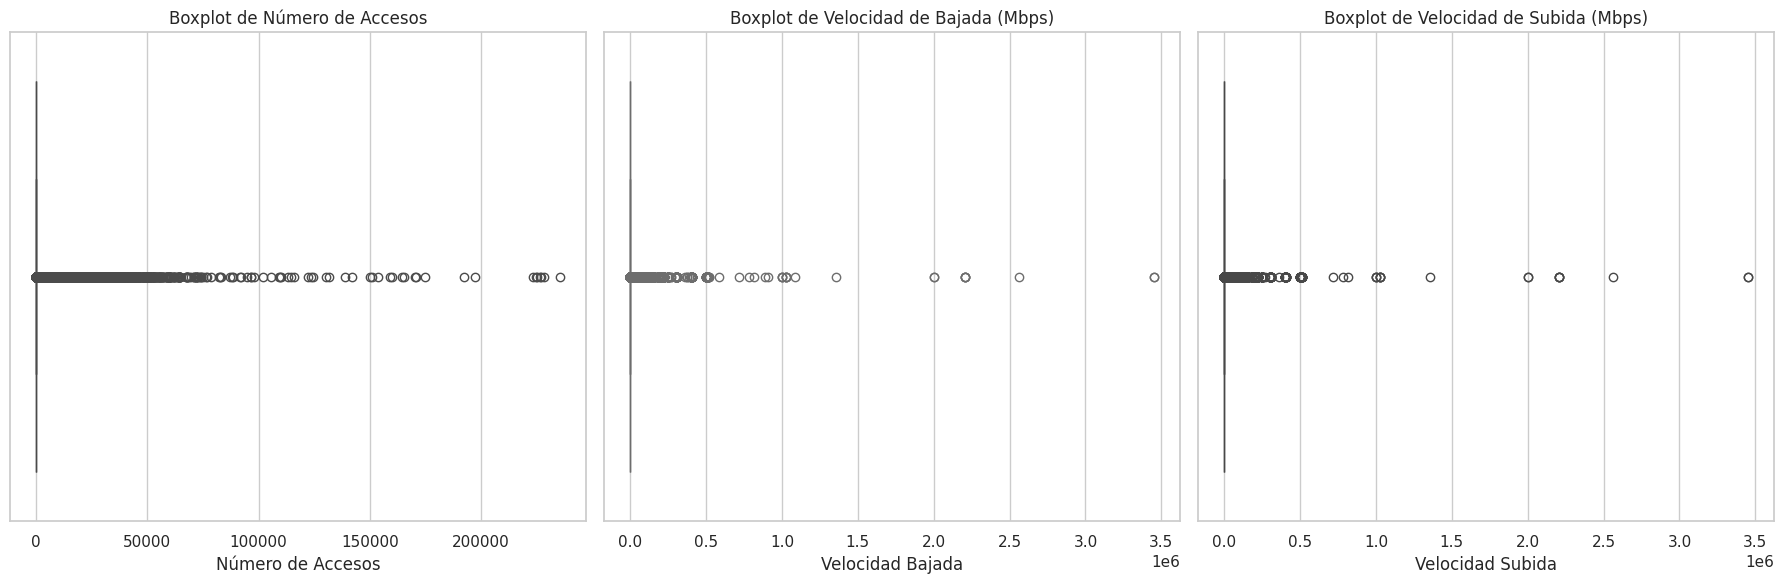

In [22]:
# --- BOXPLOTS: Distribución de variables numéricas ---
fig_box, axes_box = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x=pdf['NUM_ACCESOS'], ax=axes_box[0], color='steelblue')
axes_box[0].set_title('Boxplot de Número de Accesos')
axes_box[0].set_xlabel('Número de Accesos')

sns.boxplot(x=pdf['VEL_BAJADA'], ax=axes_box[1], color='salmon')
axes_box[1].set_title('Boxplot de Velocidad de Bajada (Mbps)')
axes_box[1].set_xlabel('Velocidad Bajada')

sns.boxplot(x=pdf['VEL_SUBIDA'], ax=axes_box[2], color='mediumseagreen')
axes_box[2].set_title('Boxplot de Velocidad de Subida (Mbps)')
axes_box[2].set_xlabel('Velocidad Subida')

plt.tight_layout()
plt.show()

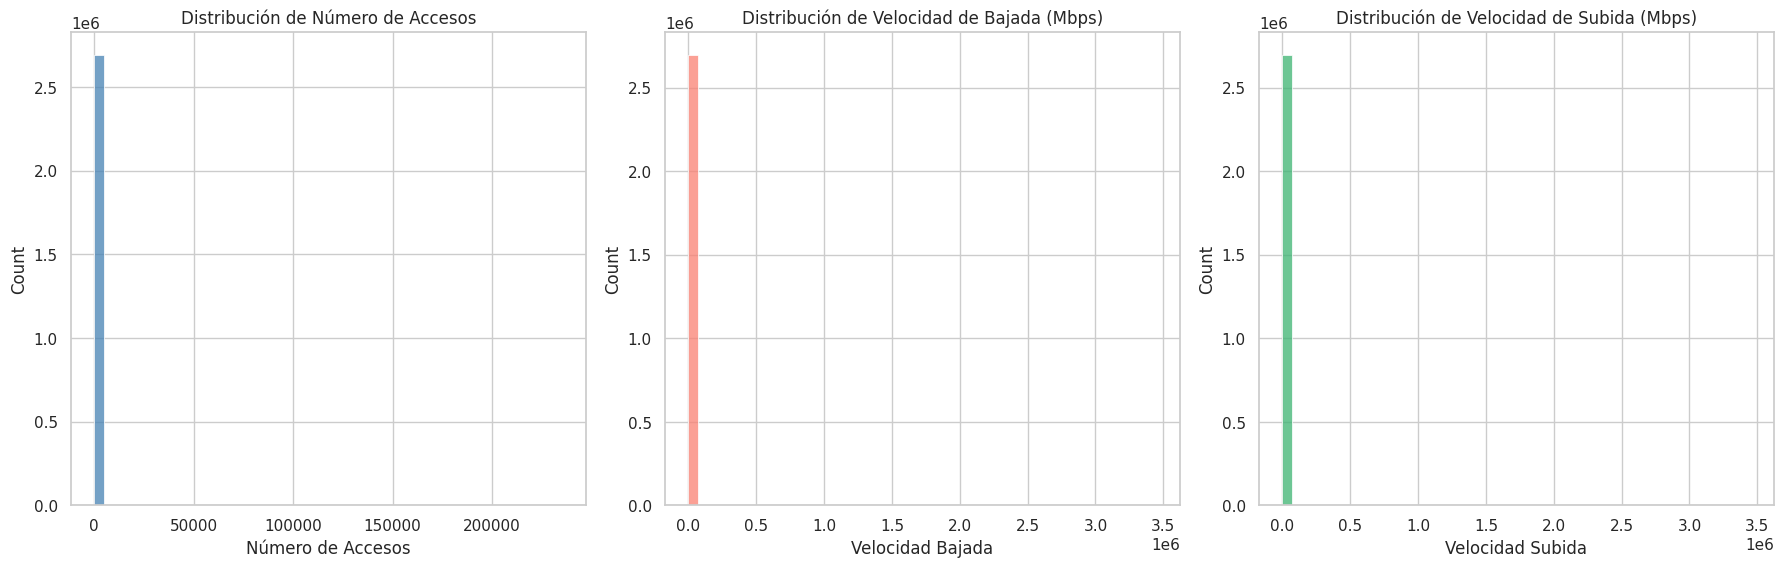

In [23]:
# --- HISTOGRAMAS: Distribución de variables numéricas ---
fig_hist, axes_hist = plt.subplots(1, 3, figsize=(18, 6))

sns.histplot(pdf['NUM_ACCESOS'].dropna(), ax=axes_hist[0], color='steelblue', bins=50)
axes_hist[0].set_title('Distribución de Número de Accesos')
axes_hist[0].set_xlabel('Número de Accesos')

sns.histplot(pdf['VEL_BAJADA'].dropna(), ax=axes_hist[1], color='salmon', bins=50)
axes_hist[1].set_title('Distribución de Velocidad de Bajada (Mbps)')
axes_hist[1].set_xlabel('Velocidad Bajada')

sns.histplot(pdf['VEL_SUBIDA'].dropna(), ax=axes_hist[2], color='mediumseagreen', bins=50)
axes_hist[2].set_title('Distribución de Velocidad de Subida (Mbps)')
axes_hist[2].set_xlabel('Velocidad Subida')

plt.tight_layout()
plt.show()

Los boxplots e histogramas revelan la distribución de las variables numéricas clave. Se espera una distribución fuertemente sesgada a la derecha en el número de accesos, dado que la mayoría de los municipios tienen cobertura baja mientras que las grandes ciudades concentran una proporción alta del total de conexiones. Las velocidades también presentarán alta variabilidad dependiendo de la tecnología utilizada.

/tmp/ipykernel_3112616/2742859463.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tec_counts.values, y=tec_counts.index, ax=axes[0], palette='Blues_r')
/tmp/ipykernel_3112616/2742859463.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg_counts.values, y=seg_counts.index, ax=axes[1], palette='Greens_r')
/tmp/ipykernel_3112616/2742859463.py:20: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3112616/2742859463.py:20: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/estudiante/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 141 (\x8d) missing from f

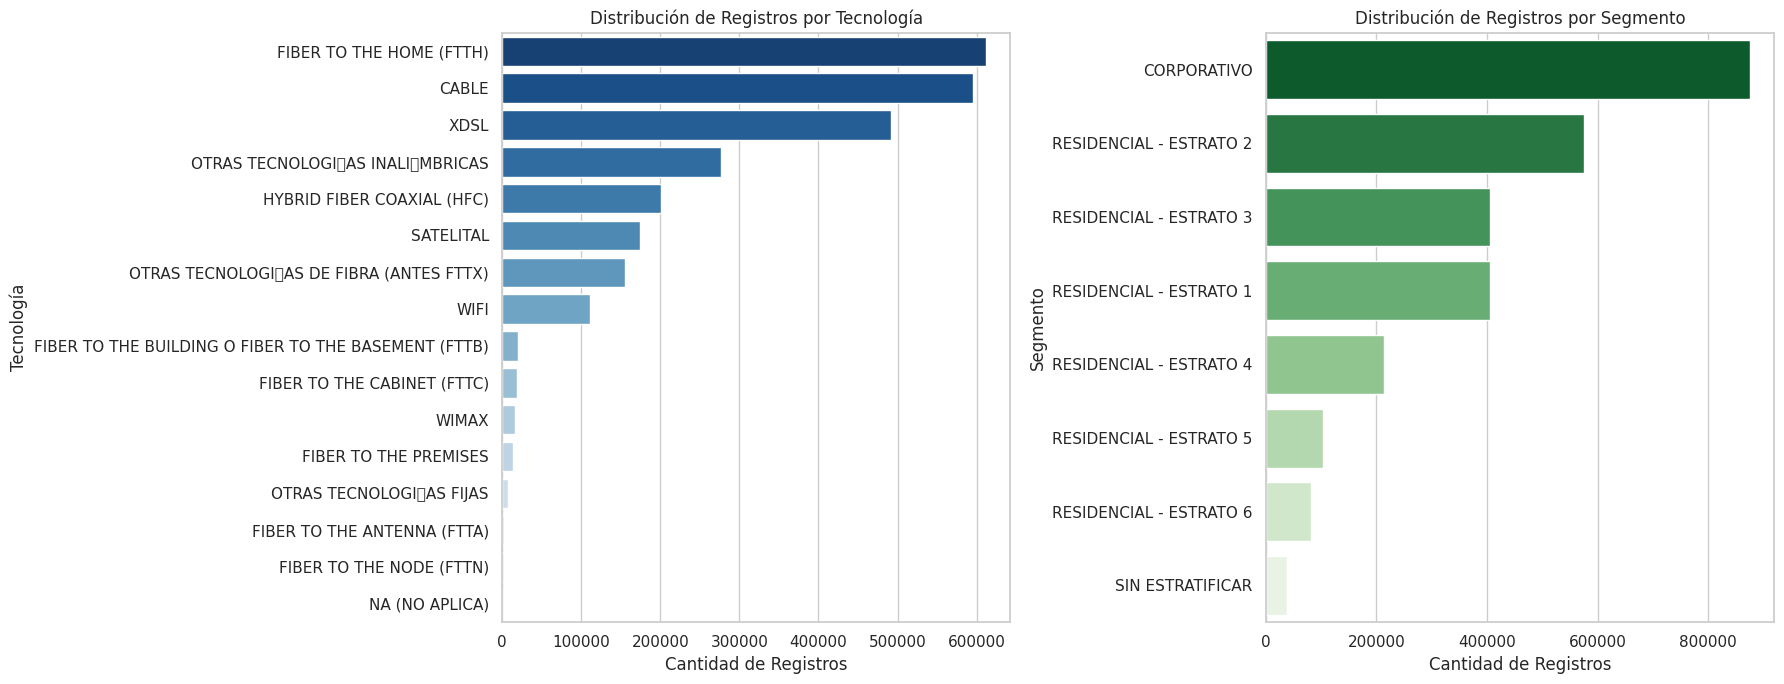

In [24]:
# --- BARRAS: Distribución por Tecnología y Segmento ---
pdf_cat = dfPy03.select('TECNOLOGIA', 'SEGMENTO').toPandas()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico de barras por Tecnología
tec_counts = pdf_cat['TECNOLOGIA'].value_counts()
sns.barplot(x=tec_counts.values, y=tec_counts.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Distribución de Registros por Tecnología')
axes[0].set_xlabel('Cantidad de Registros')
axes[0].set_ylabel('Tecnología')

# Gráfico de barras por Segmento
seg_counts = pdf_cat['SEGMENTO'].value_counts()
sns.barplot(x=seg_counts.values, y=seg_counts.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Distribución de Registros por Segmento')
axes[1].set_xlabel('Cantidad de Registros')
axes[1].set_ylabel('Segmento')

plt.tight_layout()
plt.show()

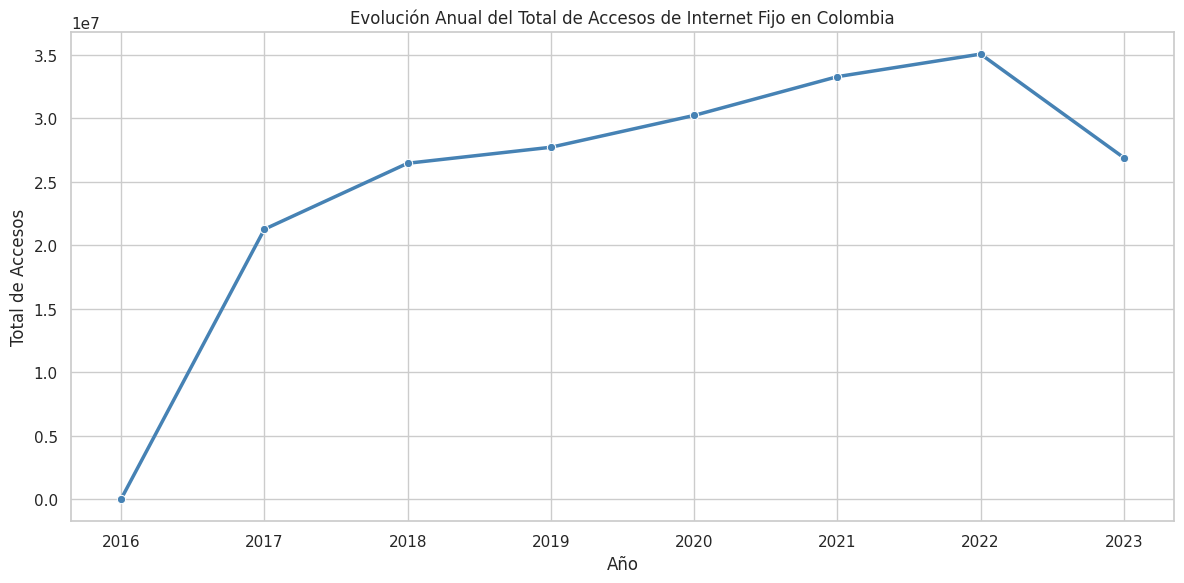

In [25]:
# --- LÍNEA: Evolución anual del total de accesos ---
pdf_anual = dfPy03.groupby('AÑO') \
    .agg(F.sum('NUM_ACCESOS').alias('TOTAL_ACCESOS')) \
    .orderBy('AÑO') \
    .toPandas()

plt.figure(figsize=(12, 6))
sns.lineplot(data=pdf_anual, x='AÑO', y='TOTAL_ACCESOS', marker='o', color='steelblue', linewidth=2.5)
plt.title('Evolución Anual del Total de Accesos de Internet Fijo en Colombia')
plt.xlabel('Año')
plt.ylabel('Total de Accesos')
plt.xticks(pdf_anual['AÑO'])
plt.tight_layout()
plt.show()

La gráfica de evolución temporal permite identificar la tendencia de crecimiento en la penetración del internet fijo en Colombia. Un crecimiento sostenido indicará una expansión progresiva de la infraestructura, mientras que caídas o estancamientos en ciertos años pueden estar relacionados con factores económicos o limitaciones regulatorias.

/tmp/ipykernel_3112616/1581217841.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf_dep, x='TOTAL_ACCESOS', y='NOM_DEP', palette='Blues_r')
/tmp/ipykernel_3112616/1581217841.py:13: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3112616/1581217841.py:13: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/estudiante/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/estudiante/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


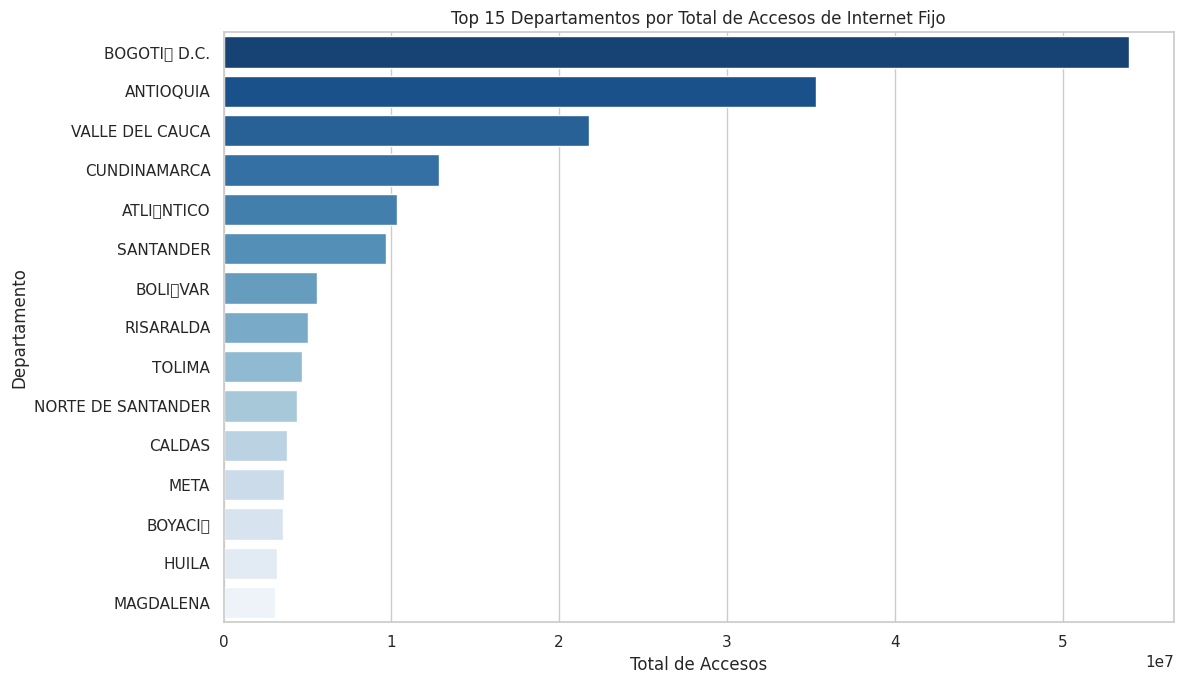

In [26]:
# --- BARRAS HORIZONTALES: Top 15 departamentos por accesos ---
pdf_dep = dfPy03.groupby('NOM_DEP') \
    .agg(F.sum('NUM_ACCESOS').alias('TOTAL_ACCESOS')) \
    .orderBy('TOTAL_ACCESOS', ascending=False) \
    .limit(15) \
    .toPandas()

plt.figure(figsize=(12, 7))
sns.barplot(data=pdf_dep, x='TOTAL_ACCESOS', y='NOM_DEP', palette='Blues_r')
plt.title('Top 15 Departamentos por Total de Accesos de Internet Fijo')
plt.xlabel('Total de Accesos')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

In [27]:
import scipy.stats as stats

## Cálculo de la correlación entre Velocidad de Bajada y Número de Accesos
df_temp = dfPy03.select('VEL_BAJADA', 'NUM_ACCESOS').dropna().toPandas()

# Calculamos Spearman y el p-valor
coef_spearman, p_valor = stats.spearmanr(df_temp['VEL_BAJADA'], df_temp['NUM_ACCESOS'])

print('--- Prueba de Correlación de Spearman ---')
print(f'Coeficiente de correlación (rho): {coef_spearman:.4f}')
print(f'P-valor: {p_valor:.4e}')

alpha = 0.05
if p_valor < alpha:
    print(f'Con p-valor < {alpha}: Existe correlación estadísticamente significativa.')
else:
    print(f'Con p-valor >= {alpha}: No hay evidencia suficiente de correlación.')

--- Prueba de Correlación de Spearman ---
Coeficiente de correlación (rho): 0.0225
P-valor: 2.7205e-298
Con p-valor < 0.05: Existe correlación estadísticamente significativa.


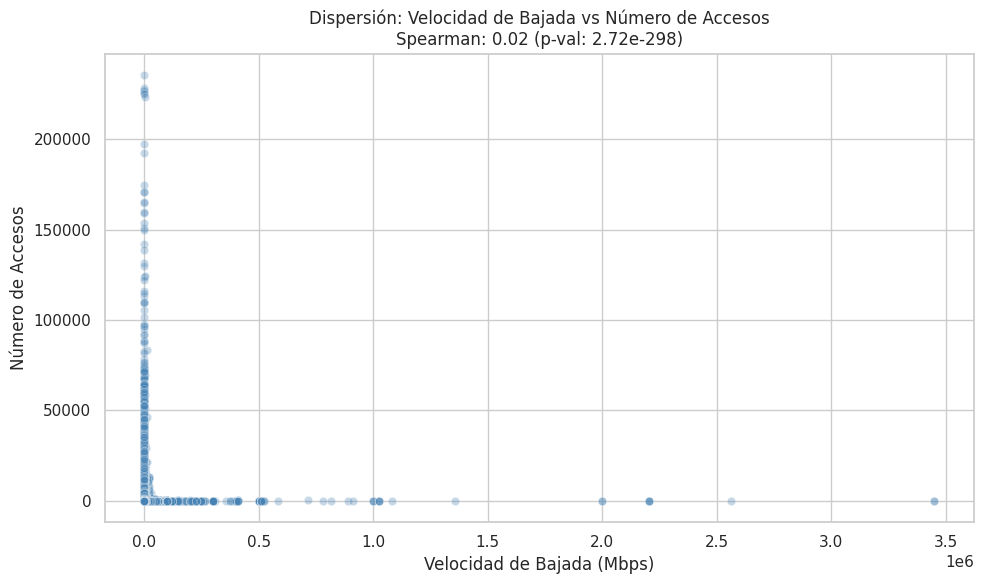

In [28]:
# --- DISPERSIÓN: Velocidad de Bajada vs Número de Accesos ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_temp, x='VEL_BAJADA', y='NUM_ACCESOS', alpha=0.3, color='steelblue')
plt.title(f'Dispersión: Velocidad de Bajada vs Número de Accesos\nSpearman: {coef_spearman:.2f} (p-val: {p_valor:.2e})')
plt.xlabel('Velocidad de Bajada (Mbps)')
plt.ylabel('Número de Accesos')
plt.tight_layout()
plt.show()

El diagrama de dispersión permite explorar visualmente la relación entre la velocidad de bajada ofrecida y el número de accesos por registro. Una correlación positiva indicaría que las tecnologías con mayores velocidades también concentran más suscriptores, lo que tendría implicaciones sobre la calidad del servicio disponible en los municipios con mayor cobertura.

/tmp/ipykernel_3112616/1741012904.py:14: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3112616/1741012904.py:14: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/estudiante/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/estudiante/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


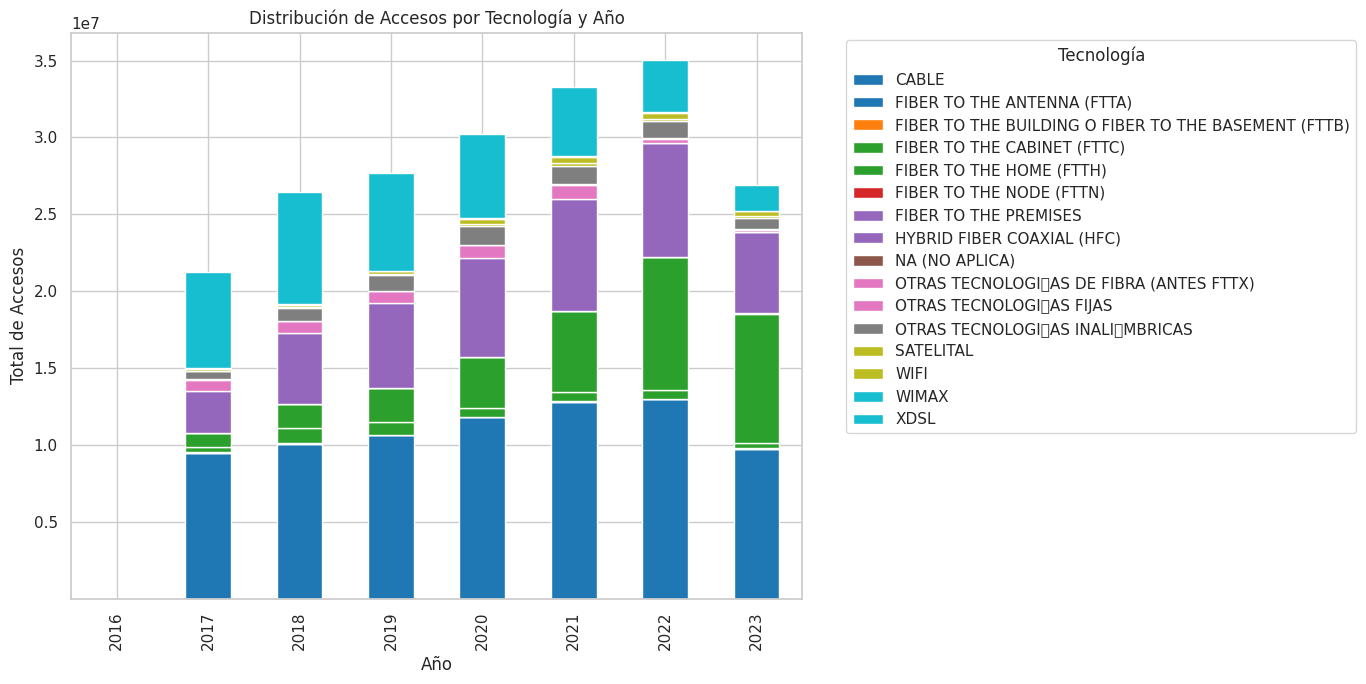

In [35]:
# --- BARRAS APILADAS: Accesos por Tecnología y Año ---
pdf_tec_anual = dfPy03.groupby('AÑO', 'TECNOLOGIA') \
    .agg(F.sum('NUM_ACCESOS').alias('TOTAL_ACCESOS')) \
    .orderBy('AÑO') \
    .toPandas()

pivot_tec = pdf_tec_anual.pivot(index='AÑO', columns='TECNOLOGIA', values='TOTAL_ACCESOS').fillna(0)

pivot_tec.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab10')
plt.title('Distribución de Accesos por Tecnología y Año')
plt.xlabel('Año')
plt.ylabel('Total de Accesos')
plt.legend(title='Tecnología', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

La gráfica de barras apiladas muestra la composición tecnológica del internet fijo en Colombia por año. Se espera observar una transición progresiva desde tecnologías tradicionales como XDSL hacia tecnologías de mayor velocidad como fibra óptica y HFC, lo que refleja el avance en la calidad de la infraestructura disponible en los municipios a lo largo del tiempo.

### 4 - Estadísticas generales

In [30]:
# Total de accesos por año
print("Total de accesos por AÑO:")
dfPy03.groupby("AÑO") \
    .agg(F.sum("NUM_ACCESOS").alias("TOTAL_ACCESOS")) \
    .orderBy("AÑO") \
    .show()

# Total de accesos por departamento
print("Top 10 departamentos por número de accesos:")
dfPy03.groupby("NOM_DEP") \
    .agg(F.sum("NUM_ACCESOS").alias("TOTAL_ACCESOS")) \
    .orderBy("TOTAL_ACCESOS", ascending=False) \
    .show(10, truncate=False)

Total de accesos por AÑO:
+----+-------------+
| AÑO|TOTAL_ACCESOS|
+----+-------------+
|2016|          456|
|2017|     21252716|
|2018|     26451208|
|2019|     27712782|
|2020|     30219951|
|2021|     33274265|
|2022|     35053387|
|2023|     26887310|
+----+-------------+

Top 10 departamentos por número de accesos:
+------------------+-------------+
|NOM_DEP           |TOTAL_ACCESOS|
+------------------+-------------+
|BOGOTI D.C.      |53943370     |
|ANTIOQUIA         |35286776     |
|VALLE DEL CAUCA   |21760739     |
|CUNDINAMARCA      |12821114     |
|ATLINTICO        |10355735     |
|SANTANDER         |9654504      |
|BOLIVAR          |5544628      |
|RISARALDA         |5047607      |
|TOLIMA            |4689331      |
|NORTE DE SANTANDER|4358075      |
+------------------+-------------+
only showing top 10 rows



In [31]:
# Total de accesos por tecnología
print("Accesos por TECNOLOGIA:")
dfPy03.groupby("TECNOLOGIA") \
    .agg(F.sum("NUM_ACCESOS").alias("TOTAL_ACCESOS")) \
    .orderBy("TOTAL_ACCESOS", ascending=False) \
    .show(truncate=False)

# Total de accesos por segmento
print("Accesos por SEGMENTO:")
dfPy03.groupby("SEGMENTO") \
    .agg(F.sum("NUM_ACCESOS").alias("TOTAL_ACCESOS")) \
    .orderBy("TOTAL_ACCESOS", ascending=False) \
    .show(truncate=False)

Accesos por TECNOLOGIA:
+----------------------------------------------------+-------------+
|TECNOLOGIA                                          |TOTAL_ACCESOS|
+----------------------------------------------------+-------------+
|CABLE                                               |77563124     |
|HYBRID FIBER COAXIAL (HFC)                          |39341226     |
|XDSL                                                |34922032     |
|FIBER TO THE HOME (FTTH)                            |30328760     |
|OTRAS TECNOLOGIAS INALIMBRICAS                    |6616321      |
|OTRAS TECNOLOGIAS DE FIBRA (ANTES FTTX)            |4409547      |
|FIBER TO THE CABINET (FTTC)                         |4199045      |
|WIFI                                                |1806922      |
|SATELITAL                                           |724760       |
|WIMAX                                               |393693       |
|OTRAS TECNOLOGIAS FIJAS                            |234834       |
|FIBER TO 

### 5 - Categorías y cambio sobre el tipo de datos de las categorías

In [32]:
# Ver todos los valores únicos en SEGMENTO
dfPy03.groupby("SEGMENTO").count().orderBy("count", ascending=False).show(truncate=False)

+-----------------------+------+
|SEGMENTO               |count |
+-----------------------+------+
|CORPORATIVO            |874906|
|RESIDENCIAL - ESTRATO 2|574685|
|RESIDENCIAL - ESTRATO 3|405835|
|RESIDENCIAL - ESTRATO 1|404909|
|RESIDENCIAL - ESTRATO 4|213923|
|RESIDENCIAL - ESTRATO 5|104359|
|RESIDENCIAL - ESTRATO 6|81506 |
|SIN ESTRATIFICAR       |38137 |
+-----------------------+------+



In [38]:
# Consolidación de categorías en SEGMENTO
dfPy03 = dfPy03.withColumn("SEGMENTO_AGRUPADO",
    F.when(F.col("SEGMENTO").like("RESIDENCIAL%"), "RESIDENCIAL")
    .when(F.col("SEGMENTO") == "CORPORATIVO", "CORPORATIVO")
    .otherwise("OTRO")
)

# Consolidación de tecnologías en grupos de infraestructura
dfPy03 = dfPy03.withColumn('TIPO_TECNOLOGIA',
    F.when(
        (F.col('TECNOLOGIA').like('%FIBRA%')) |
        (F.col('TECNOLOGIA').like('%FTTH%')) |
        (F.col('TECNOLOGIA').like('%FTTB%')) |
        (F.col('TECNOLOGIA').like('%FTTC%')) |
        (F.col('TECNOLOGIA').like('%FTTN%')) |
        (F.col('TECNOLOGIA').like('%FTTP%')) |
        (F.col('TECNOLOGIA').like('%FTTA%')) |
        (F.col('TECNOLOGIA') == 'HYBRID FIBER COAXIAL (HFC)'), 'FIBRA_Y_HFC')
    .when(F.col('TECNOLOGIA') == 'CABLE', 'CABLE')
    .when(F.col('TECNOLOGIA') == 'XDSL', 'XDSL')
    .when(F.col('TECNOLOGIA') == 'SATELITAL', 'SATELITAL')
    .when(
        (F.col('TECNOLOGIA').like('%INAL%')) |
        (F.col('TECNOLOGIA') == 'WIFI') |
        (F.col('TECNOLOGIA') == 'WIMAX'), 'INALAMBRICO')
    .otherwise('OTRO')
)

print("Categorías de SEGMENTO_AGRUPADO tras consolidación:")
dfPy03.groupby("SEGMENTO_AGRUPADO").count().orderBy(F.col("count").desc()).show()

print("Categorías de TIPO_TECNOLOGIA tras consolidación:")
dfPy03.groupby("TIPO_TECNOLOGIA").count().orderBy(F.col("count").desc()).show()

Categorías de SEGMENTO_AGRUPADO tras consolidación:
+-----------------+-------+
|SEGMENTO_AGRUPADO|  count|
+-----------------+-------+
|      RESIDENCIAL|1785217|
|      CORPORATIVO| 874906|
|             OTRO|  38137|
+-----------------+-------+

Categorías de TIPO_TECNOLOGIA tras consolidación:
+---------------+-------+
|TIPO_TECNOLOGIA|  count|
+---------------+-------+
|    FIBRA_Y_HFC|1012983|
|          CABLE| 594878|
|           XDSL| 492248|
|    INALAMBRICO| 403441|
|      SATELITAL| 174246|
|           OTRO|  20464|
+---------------+-------+



In [ ]:
# Verificación final del dataframe limpio
print("Conteo de nulos tras tratamiento completo:")
dfPy03.select(count_missings(dfPy03)).show()

print("Total de registros finales:", dfPy03.count())
dfPy03.show(5)

Conteo de nulos tras tratamiento completo:
+---+---------+---------+-------+-------+-------+-------+--------+----------+----------+----------+-----------+-----------------+---------------+
|AÑO|TRIMESTRE|PROVEEDOR|COD_DEP|NOM_DEP|COD_MUN|NOM_MUN|SEGMENTO|TECNOLOGIA|VEL_BAJADA|VEL_SUBIDA|NUM_ACCESOS|SEGMENTO_AGRUPADO|TIPO_TECNOLOGIA|
+---+---------+---------+-------+-------+-------+-------+--------+----------+----------+----------+-----------+-----------------+---------------+
|  0|        0|        0|      0|      0|      0|      0|       0|         0|         0|         0|          0|                0|              0|
+---+---------+---------+-------+-------+-------+-------+--------+----------+----------+----------+-----------+-----------------+---------------+

Total de registros finales: 2698260
